# LINEARITY ANALYSIS

In [1]:
from src.system_discovery import SystemDiscovery, discoverNetwork
import src.constants as cn
from src.biomodels_iterator import BiomodelsIterator
from src.timecourse import Timecourse
from src.model import Model

import collections
import os
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import sbmlnetwork as sb # type: ignore
import tellurium as te  # type: ignore
from typing import Optional

# Helpers

In [ ]:
def checkFit(model_num: int, poly_degree=1, threshold=0.1, 
        end_time: Optional[float]=None, num_point:int=100, frac_value: float=0.0):
    print(F"Poly_degree: {poly_degree}, threshold: {threshold}")
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, end_time=end_time, num_point=num_point)
    timecourse.plot()
    timecourse.timecourse_df
    return discoverNetwork(timecourse.timecourse_df, poly_degree=poly_degree, threshold=threshold)

In [ ]:
def plotValueCDF(values, title: str="", xlabel: str = "ordinate", is_plot: bool = True):
    sorted = np.sort(values)
    length = len(sorted)
    yv = np.array(range(length))/length
    plt.plot(sorted, yv)
    plt.xlabel(xlabel)
    plt.ylabel("fraction")
    plt.title(title)
    if not is_plot:
        plt.close()


In [ ]:
def plotCDF(evaluate_df: pd.DataFrame, column: str, title: str = "", is_plot: bool = True):
    list_strs = [v for v in evaluate_df[column] if isinstance(v, str)]
    value_arr: np.ndarray
    if len(list_strs) > 0:
        values = []
        [values.extend(eval(v)) for v in list_strs]
        value_arr = np.array(values)
    else:
        value_arr = evaluate_df[column].values  # type: ignore
    sorted_r2 = np.sort(value_arr)
    length = len(sorted_r2)
    yv = np.array(range(length))/length
    plt.plot(sorted_r2, yv)
    plt.xlabel("r-squared")
    plt.ylabel("fraction")
    plt.title(title)
    if not is_plot:
        plt.close()

#plotCDF("deg1_values", is_plot=False)
print("OK!")

# Detailed Analysis

## BioModels 8

In [ ]:
checkFit(8, num_point=1000)

## BioModels 206

In [ ]:
checkFit(206, threshold=0.001, poly_degree=1, num_point=1000, end_time=5)

## BioModels 181

In [ ]:
checkFit(181, threshold=0.1, poly_degree=1, num_point=1000)

# Analysis of fits

In [ ]:
for threshold in ["0.001", "0.01", "0.1", "1.0"]:
    path = os.path.join(cn.DATA_DIR, "evaluate_monomial_models-" + threshold + ".csv")
    df = pd.read_csv(path)
    df["deg1_term_density"] = df["deg1_num_nonzero_term"]/(df["num_species"]*(df["num_species"] + 1))
    plt.figure()
    plotCDF(df, "deg1_values", title=f"Number Models: {len(df)}, Threshold={threshold}")
    plotCDF(df, "deg1_min")
    plotCDF(df, "deg1_max")
    _ = plt.legend(["all species r2", "min r2 in model", "max r2 in model"])
    _ = plt.title(f"Number Models: {len(df)}, Threshold={threshold}")
    plt.figure()
    plotValueCDF(df["deg1_term_density"].values, xlabel="term density")

# Perturbations

## BioModels 181

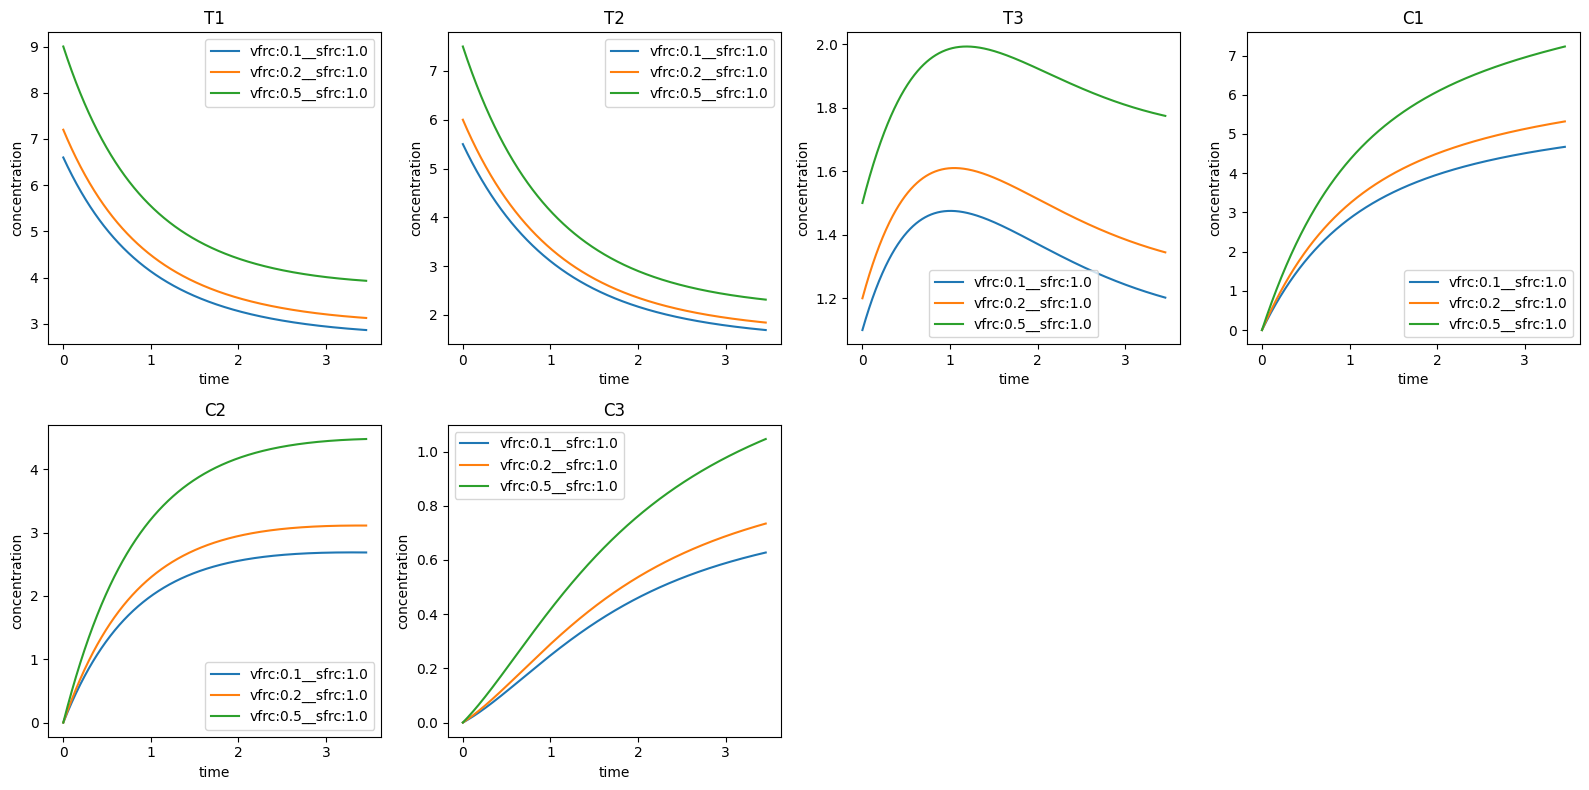

In [2]:
model = Model.makeBiomodel(model_num=181)
timecourse_df = Timecourse.makeTimecourses(
        model, num_point=1000,
        perturbation_value_fraction=[0.1, 0.2, 0.5],
        perturbation_species_fraction=[1.0],
        is_plot=True
        
    )
#timecourse_df


ds1/dt = 54.501 + -257.119 * s1 + -239.110 * at + -999.766 * s2 + 2671.475 * s3 + -80.760 * na + -313.154 * s4 + 537.840 * s5 + -6362.560 * s6 + 26566.881 * s6o
dat/dt = 584.317 + -470.522 * s1 + -491.998 * at + -1858.970 * s2 + 4740.896 * s3 + -1113.078 * na + -488.515 * s4 + 999.987 * s5 + -5694.635 * s6 + 40444.826 * s6o
ds2/dt = -4.093 + 257.069 * s1 + 239.121 * at + 990.041 * s2 + -2672.284 * s3 + 80.119 * na + 313.454 * s4 + -537.862 * s5 + 6363.242 * s6 + -26567.093 * s6o
ds3/dt = -185.075 + -3.149 * s1 + 1.942 * at + 13.332 * s2 + -42.058 * s3 + 292.691 * na + 0.511 * s4 + 8.019 * s5 + -1937.963 * s6 + 1888.031 * s6o
dna/dt = -65.674 + -1.110 * s1 + 2.591 * at + -3.567 * s2 + 24.648 * s3 + 73.409 * na + -0.035 * s4 + 9.424 * s5 + -1330.802 * s6 + 1855.885 * s6o
ds4/dt = -298.663 + -39.547 * s1 + -19.333 * at + -132.740 * s2 + 631.874 * s3 + 545.910 * na + -145.018 * s4 + 64.563 * s5 + -3481.181 * s6 + 8709.538 * s6o
ds5/dt = 438.844 + 41.506 * s1 + 16.860 * at + 136.994 * s2 +

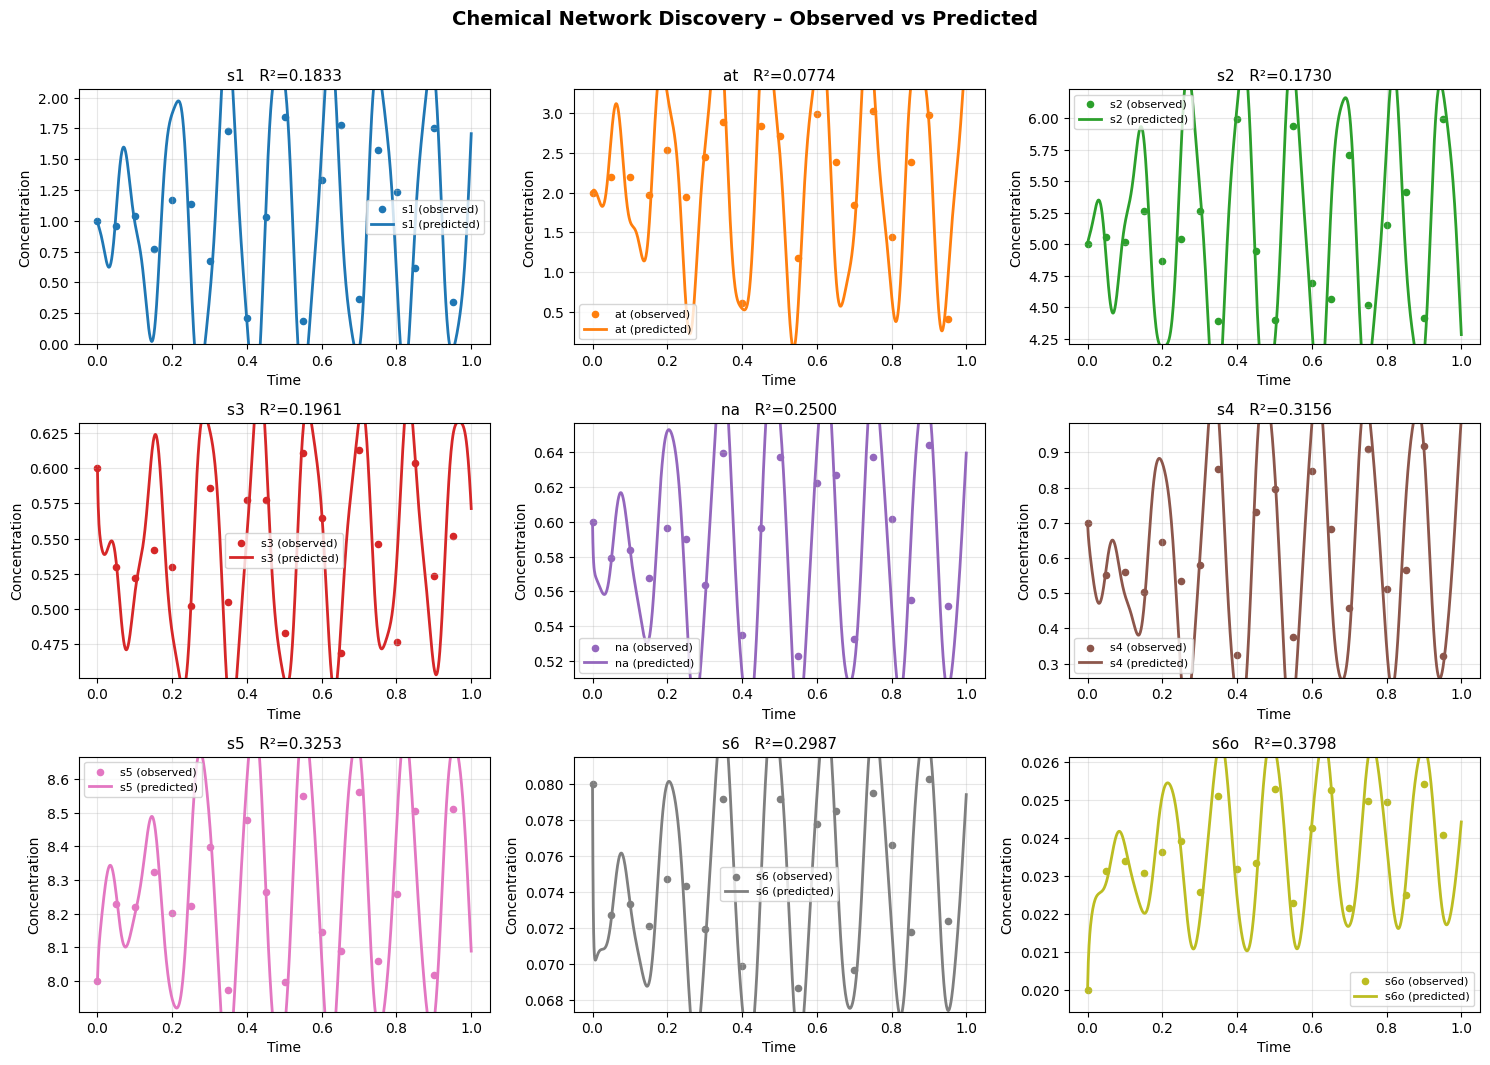

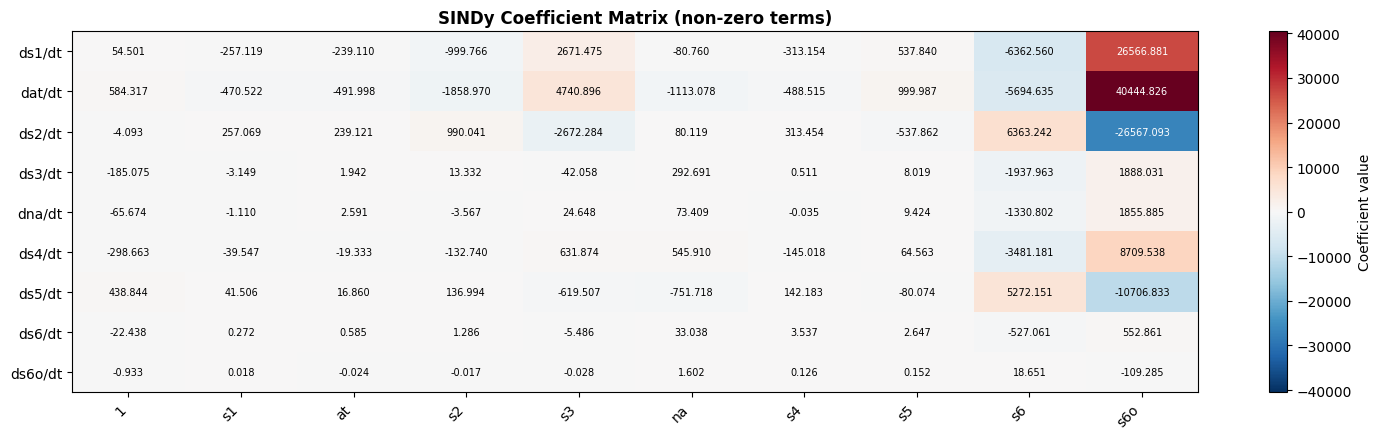

In [16]:
model_num =206
poly_degree = 1
threshold = 0.01
value_frc = 0.0
model = Model.makeBiomodel(model_num=model_num)
base_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        end_time=1,
        perturbation_value_fraction=[0.0],
        perturbation_species_fraction=[1.0],
        is_plot=False
        
    )[0]
change_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        end_time=1,
        perturbation_value_fraction=[value_frc],
        perturbation_species_fraction=[1.0],
        is_plot=False
        
    )[0]
sd = discoverNetwork(base_timecourse.timecourse_df,
        test_df=change_timecourse.timecourse_df,
        poly_degree=poly_degree, 
        threshold=threshold)

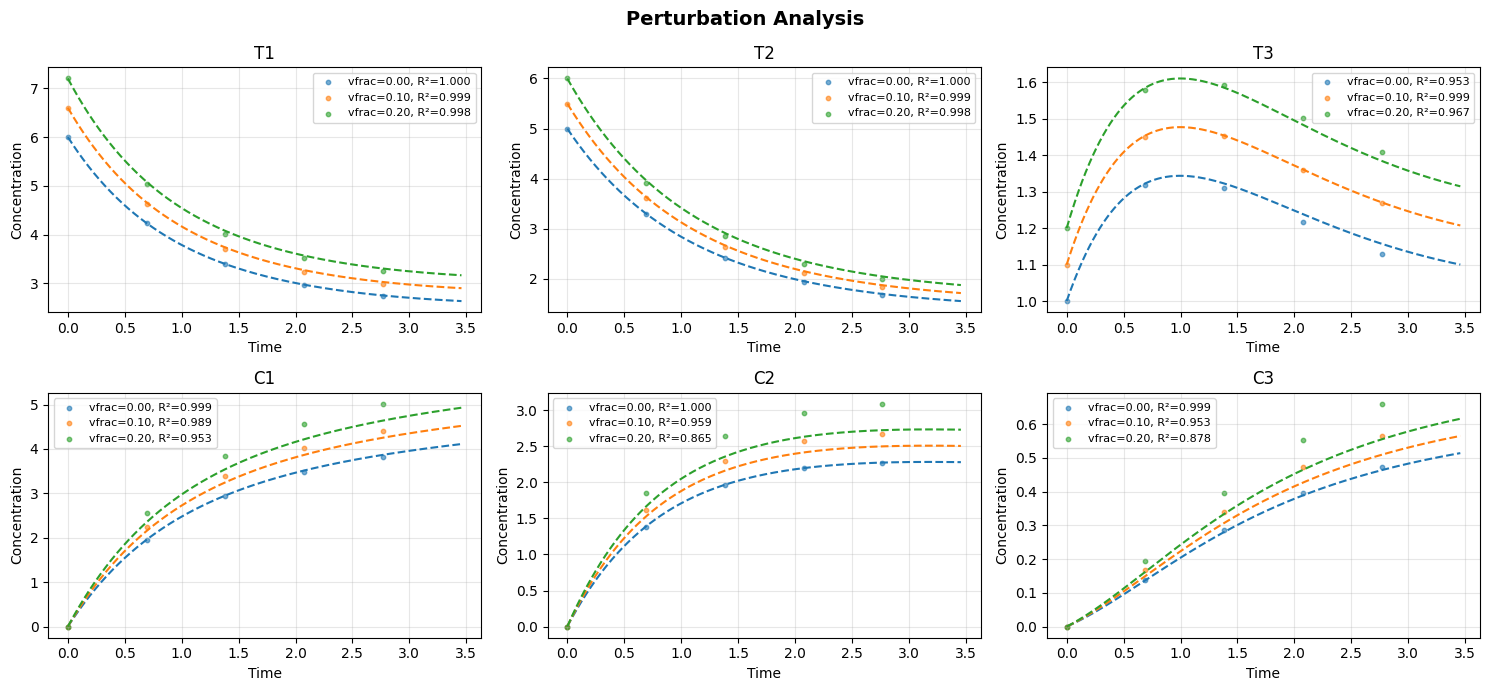

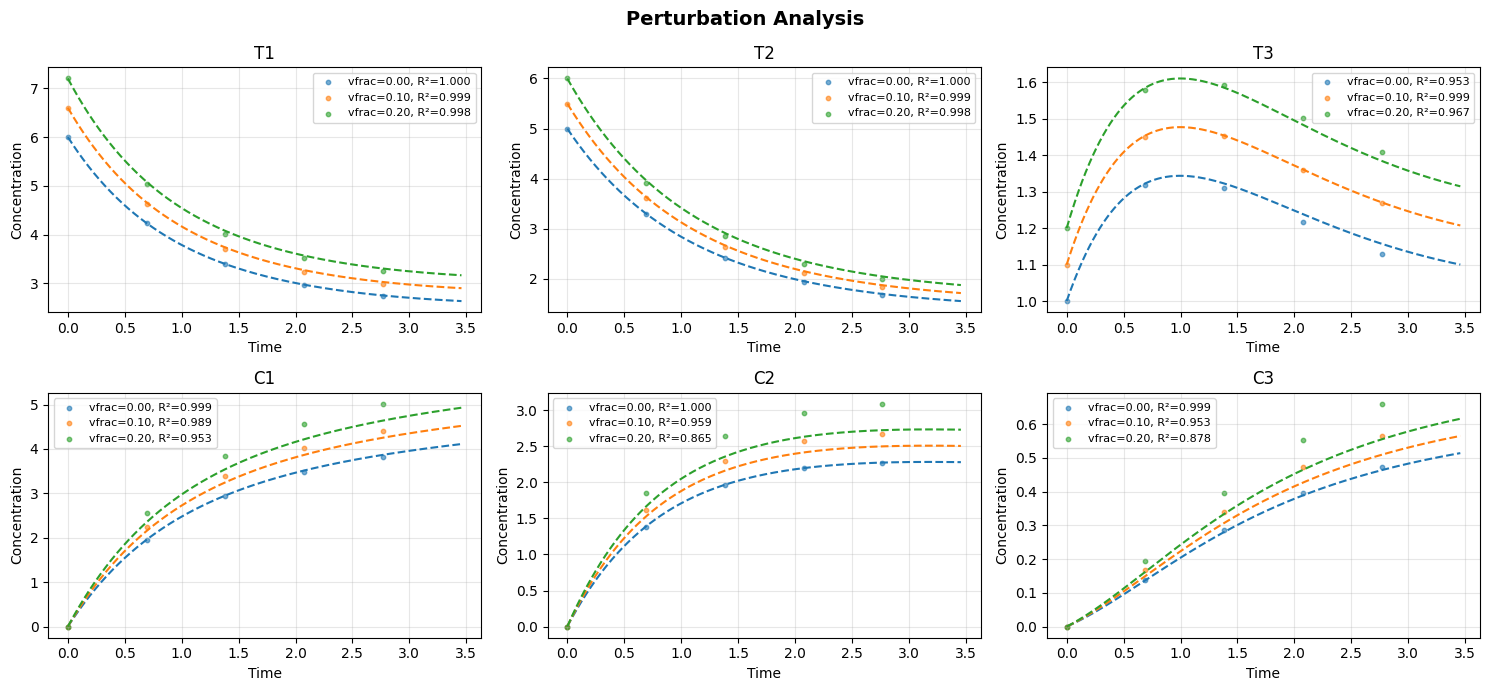

In [ ]:
model_num =181
poly_degree = 1
threshold = 0.01
value_frc = 0.0
model = Model.makeBiomodel(model_num=model_num)
base_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        perturbation_value_fraction=[0.0],
        perturbation_species_fraction=[1.0],
        is_plot=False
        
    )[0]
change_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        perturbation_value_fraction=[value_frc],
        perturbation_species_fraction=[1.0],
        is_plot=False)[0]
training_df = base_timecourse.timecourse_df
test_df = change_timecourse.timecourse_df    
SystemDiscovery.perturbationAnalysis(model, training_df, threshold=threshold,
                    perturbations=[0.0, 0.1, 0.5])